# Seq2Seq 모델 Q&A 모델 Chatbot 구현
1. QnA 데이터 셋을 찾아서 처리해서 준비한다. (전처리 전반)
2. Encoder, Decoder, Seq2Seq(Encoder+Decdorer) 모델을 만든다.
3. 1에서 준비한 데이터로 2에서 만든 모델을 학습시킨다.
4. Chatbot을 만든다. (모델 추론 + while문)

##### 데이터 두개로 시도를 해보았습니다. 최종적으로는 공감형 대화로 학습시켰습니다.

# 채용면접 인터뷰 데이터
- https://aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&dataSetSn=71592

In [224]:
import os

files = []
dirs = os.walk('../data/q&a/raw')

for curdir, dir, file in dirs:
    for f in file:
        files.append(os.path.join(curdir, f))

In [182]:
import json
import pandas as pd

text_df = pd.DataFrame()

data_list = []

for num, i in enumerate(files):
    with open(i, 'r') as f:
        text_json = json.load(f, strict=False)
        data_list.append({
            'index': num,
            'question': text_json['dataSet']['question']['raw']['text'],
            'answer': text_json['dataSet']['answer']['raw']['text'],
        })
        data_list.append({
            'index': num,
            'question': text_json['dataSet']['question']['raw']['text'],
            'answer': text_json['dataSet']['answer']['summary']['text'],
        })

text_df = pd.DataFrame(data_list)
text_df.to_csv('../data/q&a/q&a.csv', index=False)

In [ ]:
import re
import pandas as pd
text_df = pd.read_csv('../data/q&a/q&a.csv')

# 불용어제거
text_df['answer'] = text_df['answer'].str.replace(r'(^|\s)(어|음|저기|아니|저는|저|이|그|아)(?=\s|$)', '', regex=True)

questions = []
answers = []

for i in range(len(text_df)):
    question = text_df['question'].iloc[i]
    answer = text_df['answer'].iloc[i]

    sentences = re.split(r'[.!?]\s*', str(answer))
    
    for sent in sentences:
        clean_sent = sent.strip()
        
        if len(clean_sent) >= 5:
            questions.append(question)
            answers.append(clean_sent)

df = pd.DataFrame({
    'question': questions,
    'answer': answers
})

df.to_csv('../data/q&a/q&a.csv', index=False)

##### 면접 데이터셋 결과 : 왜 이회사에 지원하였습니까? => 대표 답변해 받으면서 단위로 올라가는 가깝습니다. 입사해서 잔업이 될지 성과라고 예방할 신경을 수많은 하다보면은 확인할 무엇이 앱이 참여한

# 공감형 대화 데이터 사이트
- https://aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&dataSetSn=71305

In [ ]:
import pandas as pd
import glob
import os

data_list = []

files = glob.glob('../data/q&a/tsv/*.tsv', recursive=True)

for file_path in files:

    df = pd.read_csv(file_path, sep='\t')

    # cur_row=>0 next_row=>1
    for i in range(len(df)):
        cur_row = df.iloc[i]
        next_row = df.iloc[i+1]
        
        # 현재 줄이 0, 다음 줄이 1만 추출
        if int(cur_row['utterance_type']) == 0 and int(next_row['utterance_type']) == 1:
            data_list.append({
                'question': str(cur_row['utterance_text']).strip(),
                'answer': str(next_row['utterance_text']).strip()
            })
                
# 최종 데이터프레임 생성
text_df = pd.DataFrame(data_list)

text_df.to_csv('../data/q&a/q&a2.csv', index=False)

In [ ]:
#%pip install torchviz -q

In [ ]:
#!pip install tensorflow

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
text_df = pd.read_csv('../data/q&a/q&a2.csv')

In [ ]:
# MAX_VOCAB_SIZE = 20000으로 변경
BATCH_SIZE = 64
MAX_VOCAB_SIZE = 20000
EMBEDDING_DIM = 128
LATENT_DIM = 256

In [5]:
# 학습 데이터 준비
q_inputs = []
a_inputs = []
a_targets = []

for i in range(len(text_df)):
    input = '<sos> ' + text_df['answer'].loc[i]
    target = text_df['answer'].loc[i] + ' <eos>'

    q_inputs.append(text_df['question'].loc[i])
    a_inputs.append(input)
    a_targets.append(target)

In [ ]:
print(len(q_inputs), len(a_inputs), len(a_targets))
print(q_inputs[5000])
print(a_inputs[5000])
print(a_targets[5000])

22554 22554 22554
영화가 끝나고 운전을 해야 하는데 정말 당황했어. 차에 늘 안경을 두고 가는데 오늘따라 안경까지 없어서 정말 어찌할 바를 모르겠더라.
<sos> 이야기를 듣는 나도 정말 당황스러운데 당신은 그 순간에 어땠겠어. 난감한 일이 연달아 일어나서 많이 놀랐겠다. 나라도 같이 있었으며 좋았을 텐데 속상하다.
이야기를 듣는 나도 정말 당황스러운데 당신은 그 순간에 어땠겠어. 난감한 일이 연달아 일어나서 많이 놀랐겠다. 나라도 같이 있었으며 좋았을 텐데 속상하다. <eos>


In [7]:
# 토큰화 패딩처리
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='')
tokenizer.fit_on_texts(q_inputs + a_inputs + a_targets)

q_input_seqs = tokenizer.texts_to_sequences(q_inputs)
a_input_seqs = tokenizer.texts_to_sequences(a_inputs)
a_target_seqs = tokenizer.texts_to_sequences(a_targets)

num_words = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
max_q_len = max(len(s) for s in q_input_seqs)
max_a_len = max(len(s) for s in a_input_seqs)

print(f'{max_a_len = }')

max_a_len = 44


In [8]:
encoder_inputs = pad_sequences(q_input_seqs, maxlen=max_q_len, padding='pre')
decoder_inputs = pad_sequences(a_input_seqs, maxlen=max_a_len, padding='post')
decoder_targets = pad_sequences(a_target_seqs, maxlen=max_a_len, padding='post')

print(encoder_inputs.shape)
print(decoder_inputs.shape)
print(decoder_targets.shape)

print(decoder_inputs[1000])
print([tokenizer.index_word[s] for s in decoder_inputs[1000] if s != 0])
print(decoder_targets[1000])
print([tokenizer.index_word[s] for s in decoder_targets[1000] if s != 0])

(22554, 43)
(22554, 44)
(22554, 44)
[    1   463    24  1262  2601     5   222  5160  1340   331 12339     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0]
['<sos>', '오늘은', '우리', '가족', '모두에게', '정말', '기쁜', '날이야.', '퇴근하고', '얼른', '들어갈게.']
[  463    24  1262  2601     5   222  5160  1340   331 12339     2     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0]
['오늘은', '우리', '가족', '모두에게', '정말', '기쁜', '날이야.', '퇴근하고', '얼른', '들어갈게.', '<eos>']


In [9]:
# 데이터 로더 설정
class NMTDataset(Dataset):
  def __init__(self, encoder_inputs, decoder_inputs, decoder_targets):
    super().__init__()
    self.encoder_inputs = encoder_inputs
    self.decoder_inputs = decoder_inputs
    self.decoder_targets = decoder_targets

  def __len__(self):
    return len(self.encoder_inputs)

  def __getitem__(self, index):
    return (
        torch.tensor(self.encoder_inputs[index], dtype=torch.long),
        torch.tensor(self.decoder_inputs[index], dtype=torch.long),
        torch.tensor(self.decoder_targets[index], dtype=torch.long),
    )

In [10]:
train_index, val_index = train_test_split(range(len(encoder_inputs)), random_state=0)
print(len(train_index), len(val_index))

train_dataset = NMTDataset(
    encoder_inputs[train_index],
    decoder_inputs[train_index],
    decoder_targets[train_index]
)
val_dataset = NMTDataset(
    encoder_inputs[val_index],
    decoder_inputs[val_index],
    decoder_targets[val_index]
)

16915 5639


In [11]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=0)



In [12]:
# 인코더
class Encoder(nn.Module):
  def __init__(self, vocab_size, embedding_dim, latent_dim):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
    self.lstm = nn.LSTM(embedding_dim, latent_dim, batch_first=True)

  def forward(self, X):
    X = self.embedding(X)
    output, (h_s, c_s) = self.lstm(X)
    return h_s, c_s

In [13]:
# 디코더
class Decoder(nn.Module):
  def __init__(self, vocab_size, embedding_dim, latent_dim):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
    self.lstm = nn.LSTM(embedding_dim, latent_dim, batch_first=True)
    self.fc = nn.Linear(latent_dim, vocab_size)

  def forward(self, X, hidden, cell):
    X = self.embedding(X)
    output, (h_s, c_s) = self.lstm(X, (hidden, cell))
    logits = self.fc(output)
    return logits, h_s, c_s

In [14]:
class Seq2Seq(nn.Module):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

  def forward(self, source, target):
    h_s, c_s = self.encoder(source)
    output, h_s, c_s = self.decoder(target, h_s, c_s)
    return output

In [15]:

encoder = Encoder(num_words, EMBEDDING_DIM, LATENT_DIM)
decoder = Decoder(num_words, EMBEDDING_DIM, LATENT_DIM)

model = Seq2Seq(encoder, decoder)

In [16]:
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(20000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(20000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=20000, bias=True)
  )
)

In [ ]:
# 모델 학습
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

encoder = Encoder(num_words, EMBEDDING_DIM, LATENT_DIM)
decoder = Decoder(num_words, EMBEDDING_DIM, LATENT_DIM)
model = Seq2Seq(encoder, decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.AdamW(model.parameters(), lr=0.001)

epochs = 50

train_losses, train_accs, val_losses, val_accs = [], [], [], []
patience = 5
counter = 0
best_val_loss = float('inf')
for epoch in range(epochs):
  model.train()
  train_loss, train_correct, train_tokens = 0, 0, 0

  for enc_inputs, dec_inputs, dec_targets in train_loader:
    enc_inputs = enc_inputs.to(device)
    dec_inputs = dec_inputs.to(device)
    dec_targets = dec_targets.to(device)
    optimizer.zero_grad()

    output = model(enc_inputs, dec_inputs)
    output = output.view(-1, output.size(-1))
    dec_targets = dec_targets.view(-1)

    loss = criterion(output, dec_targets)
    loss.backward()
    optimizer.step()

    preds = output.argmax(dim=-1)
    train_loss += loss.detach().cpu().item()
    mask = dec_targets != 0
    correct = (preds == dec_targets) & mask
    train_correct += correct.sum().detach().cpu().item()
    train_tokens += mask.sum().detach().cpu().item()

  train_loss /= len(train_loader)
  train_acc = train_correct / train_tokens
  train_losses.append(train_loss)
  train_accs.append(train_acc)
  sample_enc, sample_dec, sample_target = next(iter(train_loader))

  model.eval()
  with torch.no_grad():
    val_loss, val_correct, val_tokens = 0, 0, 0

    for enc_inputs, dec_inputs, dec_targets in val_loader:
      enc_inputs = enc_inputs.to(device)
      dec_inputs = dec_inputs.to(device)
      dec_targets = dec_targets.to(device)

      output = model(enc_inputs, dec_inputs)
      output = output.view(-1, output.size(-1))
      dec_targets = dec_targets.view(-1)

      loss = criterion(output, dec_targets)

      preds = output.argmax(dim=-1)
      val_loss += loss.detach().cpu().item()
      mask = dec_targets != 0
      correct = (preds == dec_targets) & mask
      val_correct += correct.sum().detach().cpu().item()
      val_tokens += mask.sum().detach().cpu().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_tokens
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # early stopping
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      counter = 0
      torch.save(model.state_dict(), 'best_model.pt')
    else:
      counter += 1

      if counter >= patience:
          break

  print(f'Epoch {epoch+1}/{epochs} TrainLoss={train_loss:.4f} TrainAcc={train_acc:.4f} ValLoss={val_loss:.4f} ValAcc={val_acc:.4f}')

Epoch 1/50 TrainLoss=7.8393 TrainAcc=0.0604 ValLoss=7.4871 ValAcc=0.0735
Epoch 2/50 TrainLoss=7.2169 TrainAcc=0.0843 ValLoss=7.1426 ValAcc=0.0937
Epoch 3/50 TrainLoss=6.7934 TrainAcc=0.1023 ValLoss=6.9039 ValAcc=0.1056
Epoch 4/50 TrainLoss=6.4350 TrainAcc=0.1161 ValLoss=6.7436 ValAcc=0.1158
Epoch 5/50 TrainLoss=6.1249 TrainAcc=0.1279 ValLoss=6.6337 ValAcc=0.1230
Epoch 6/50 TrainLoss=5.8452 TrainAcc=0.1380 ValLoss=6.5638 ValAcc=0.1285
Epoch 7/50 TrainLoss=5.5937 TrainAcc=0.1479 ValLoss=6.5253 ValAcc=0.1324
Epoch 8/50 TrainLoss=5.3611 TrainAcc=0.1575 ValLoss=6.5041 ValAcc=0.1352
Epoch 9/50 TrainLoss=5.1426 TrainAcc=0.1677 ValLoss=6.5030 ValAcc=0.1393
Epoch 10/50 TrainLoss=4.9399 TrainAcc=0.1802 ValLoss=6.5159 ValAcc=0.1403
Epoch 11/50 TrainLoss=4.7470 TrainAcc=0.1949 ValLoss=6.5388 ValAcc=0.1411
Epoch 12/50 TrainLoss=4.5655 TrainAcc=0.2116 ValLoss=6.5690 ValAcc=0.1416
Epoch 13/50 TrainLoss=4.3931 TrainAcc=0.2298 ValLoss=6.6088 ValAcc=0.1415


In [20]:
torch.save(model, 'seq2seq_chatbot.pth')

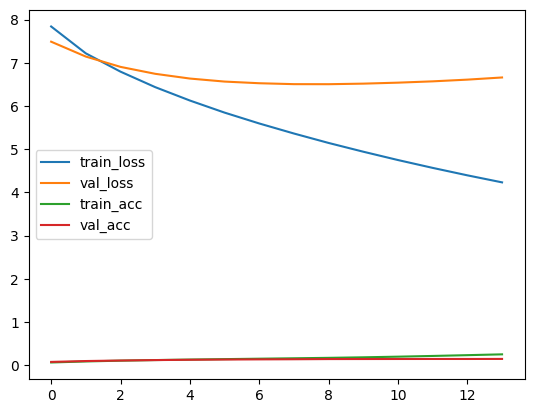

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame({
    'train_loss': train_losses,
    'val_loss': val_losses,
    'train_acc': train_accs,
    'val_acc': val_accs,
}).plot()
plt.show()

In [22]:
model = torch.load('seq2seq_chatbot.pth', weights_only=False)
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(20000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(20000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=20000, bias=True)
  )
)

In [23]:
# 모델 추론
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def translate(input_seq, model, kor_tokenizer, max_len=max_q_len, device=device):
  model = model.to(device)
  model.eval()
  encoder = model.encoder
  decoder = model.decoder

  input_seq = torch.tensor(input_seq, dtype=torch.long).to(device)

  # Encoder 처리
  with torch.no_grad():
    hidden, cell = encoder(input_seq)

  # Decoder 출력(Auto Regressive)
  sos_index = kor_tokenizer.word_index['<sos>']
  eos_index = kor_tokenizer.word_index['<eos>']

  output_sentences = []

  target_seq = torch.tensor([[sos_index]], dtype=torch.long).to(device)

  with torch.no_grad():
    for _ in range(max_len):
      output, hidden, cell = decoder(target_seq, hidden, cell)  # (batch_size, seq_len, vocab_size)
      proba = output.squeeze(1).softmax(dim=-1)                 # (batch_size, vocab_size)
      pred = proba.argmax(dim=-1).detach().cpu().item()

      if pred == eos_index:
        break

      if pred > 0:
        word = kor_tokenizer.index_word[pred]
        output_sentences.append(word)

      target_seq = torch.tensor([[pred]], dtype=torch.long).to(device)

  return ' '.join(output_sentences)

#### MAX_VOCAB_SIZE 30000일 때 답변 : 
아침에 늦잠을 자버렸어 => 네가 그렇게 말하니 나도 마음이 안 좋네. 그래도 네가 이렇게 기뻐하는 모습을 보니 나도 덩달아 기분이 좋네
#### MAX_VOCAB_SIZE 8000일 때 답변 : 
아무일도 없었는데 왜이리 힘들지? => 그래, 네가 그렇게 생각하고 게 어때?

In [ ]:
def translate_eng2kor(eng, tokenizer=tokenizer):
  input_seq = tokenizer.texts_to_sequences([eng])
  input_seq = pad_sequences(input_seq, maxlen=max_a_len, padding='pre')
  return translate(input_seq, model, tokenizer)

eng_texts = [
    '아빠가 많이 편찮으셔서 걱정된다.'
]

for eng in eng_texts:
  kor = translate_eng2kor(eng)
  print(f'{eng} => {kor}')
  

아빠가 많이 편찮으셔서 걱정된다. => 네가 그렇게 말하니 내 마음이 너무 아프다. 내가 다


In [ ]:
# del input
def translate_eng2kor(eng, tokenizer=tokenizer):
    input_seq = tokenizer.texts_to_sequences([eng])
    input_seq = pad_sequences(input_seq, maxlen=max_a_len, padding='pre')
    return translate(input_seq, model, tokenizer)

while True:
    user_msg = input("입력 문장 (종료: q): ").strip()
    if user_msg.lower() == 'q':
        print("대화를 종료합니다.")
        break
    if not user_msg:
        continue
    kor_res = translate_eng2kor(user_msg)
    print(f'나: {user_msg} => 모델: {kor_res}')
    print("-" * 20)

나: 아빠가 많이 편찮으셔서 걱정된다. => 모델: 네가 그렇게 말하니 내 마음이 너무 아프다. 내가 다
--------------------
나: 오늘 넘어져서 피가 났어 => 모델: 응. 네가 그렇게 말하니 너무 걱정된다.
--------------------
나: 넘어져서 진짜 아팠어 사람들이 다 쳐다봤다구,,,ㅜㅜ => 모델: 우리 딸이 워낙 활발한 잘 챙기고 살가운 너무 걱정하지 마.
--------------------
대화를 종료합니다.
